In [1]:
#Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
#Define the path to the Excel file
file_path = r"C:\Users\hp\Downloads\Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_ChurnData'


# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows of the fetched data
print(data.head())

  Customer_ID  Gender  Age Married          State  Number_of_Referrals  \
0   28113-HAR  Female   54      No        Haryana                    3   
1   28117-UTT  Female   56     Yes  Uttar Pradesh                    9   
2   28132-HAR  Female   28      No        Haryana                    5   
3   28145-TEL  Female   23      No      Telangana                   11   
4   28160-MAH    Male   55      No    Maharashtra                    1   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                17     Deal 1           Yes            Yes  ...   
1                23     Deal 3           Yes             No  ...   
2                27        NaN           Yes             No  ...   
3                 2     Deal 3           Yes            Yes  ...   
4                18     Deal 1           Yes            Yes  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card      76.099998   5264.250000           0.0   
1  Bank Withdraw

Data Preprocessing

In [3]:
# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

In [4]:
# List of columns to be label encoded

columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

In [5]:
# Encode categorical variables except the target variable

label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])
    

In [6]:
# Manually encode the target variable 'Customer_Status'

data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

In [7]:
# Split data into features and target

X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

In [8]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 Train Random Forest Model

In [9]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [10]:
# Train the model

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Evaluate Model

In [11]:
# Make predictions

y_pred = rf_model.predict(X_test)

In [12]:
# Evaluate the model

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[796  52]
 [124 230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       848
           1       0.82      0.65      0.72       354

    accuracy                           0.85      1202
   macro avg       0.84      0.79      0.81      1202
weighted avg       0.85      0.85      0.85      1202



In [13]:
# Feature Selection using Feature Importance

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

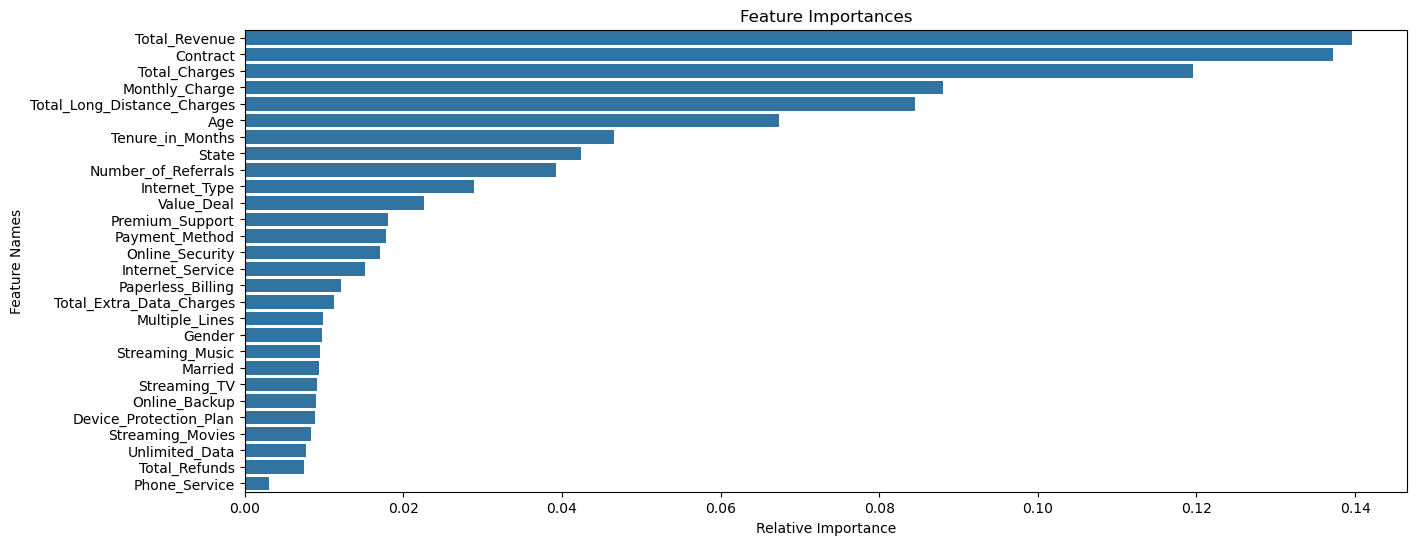

In [14]:
# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

 Use Model for Prediction on New Data

In [15]:
# Define the path to the Joiner Data Excel file
file_path = r"C:\Users\hp\Downloads\Prediction_Data.xlsx"

# Define the sheet name to read data from

sheet_name = 'vw_JoinData'

In [16]:
 #Read the data from the specified sheet into a pandas DataFrame

new_data = pd.read_excel(file_path, sheet_name=sheet_name)

In [17]:

# Display the first few rows of the fetched data

print(new_data.head())


  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   29525-TAM  Female   50     Yes   Tamil Nadu                    9   
1   29626-WES    Male   67      No  West Bengal                   10   
2   33776-BIH    Male   32     Yes        Bihar                    6   
3   33910-TEL  Female   63      No    Telangana                    4   
4   34169-RAJ    Male   51     Yes    Rajasthan                   14   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 3     Deal 5            No             No  ...   
1                22     Deal 5           Yes             No  ...   
2                10        NaN           Yes             No  ...   
3                30        NaN           Yes             No  ...   
4                30     Deal 5           Yes            Yes  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card      25.000000     78.250000           0.0   
1  Bank Withdrawal      50.1

In [18]:
# Retain the original DataFrame to preserve unencoded columns

original_data = new_data.copy()

In [19]:
# Retain the Customer_ID column

customer_ids = new_data['Customer_ID']

In [20]:
# Drop columns that won't be used for prediction in the encoded DataFrame

new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

In [21]:
# Encode categorical variables using the saved label encoders

for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

In [22]:
# Make predictions

new_predictions = rf_model.predict(new_data)

In [23]:
# Add predictions to the original DataFrame

original_data['Customer_Status_Predicted'] = new_predictions

In [24]:
# Filter the DataFrame to include only records predicted as "Churned"

original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

In [26]:
# Save the results
original_data.to_csv(r"C:\Users\hp\Downloads\Predictions.csv", index=False)

In [27]:
import joblib
joblib.dump(rf_model, 'churn_model.pkl')

['churn_model.pkl']